<a href="https://colab.research.google.com/github/Kanchanajaddu/MLassignments/blob/main/MLassignmentq2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#given question:
Problem 2 - Credit Card Fraud Detection

A bank wants to detect fraudulent transactions in real time.
Each transaction must be classified as:

0 → Legitimate

1 → Fraud

Data Set

TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
1,1200,2,1,500,1,1,0,1
2,50,24,0,200,0,0,1,0
3,5000,1,1,450,1,1,0,1
4,200,48,0,300,0,0,1,0
5,1500,3,1,700,1,0,0,1
6,75,72,0,150,0,0,1,0
7,3200,2,1,400,1,1,0,1
8,40,96,0,100,0,0,1,0
9,2100,5,1,600,1,1,0,1
10,60,120,0,120,0,0,1,0

Feature Explanation

Amount → Transaction amount

TimeSinceLastTxn → Hours since last transaction

LocationChange → 1 if location differs from previous

AvgTxnAmount → User’s average spending

IsForeignTransaction → International transaction

IsHighRiskCountry → Risky country flag

CardPresent → Physical card used (0 = online, 1 = swipe)

IsFraud → Target variable



Interpretation

Write the logistic regression equation for this dataset.

How do you interpret model coefficients (e.g., for Amount)?

What happens if two features are highly correlated?

Train a logistic regression model on this dataset

Plot ROC curve

Tune threshold (not just 0.5)

Add regularization (L1/L2) and compare results



SyntaxError: invalid character '→' (U+2192) (1486450354.py, line 7)

In [ ]:
#loading the data
data_dict={'TransactionID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Amount': [1200, 50, 5000, 200, 1500, 75, 3200, 40, 2100, 60],
    'TimeSinceLastTxn': [2, 24, 1, 48, 3, 72, 2, 96, 5, 120],
    'LocationChange': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    'AvgTxnAmount': [500, 200, 450, 300, 700, 150, 400, 100, 600, 120],
    'IsForeignTransaction': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    'IsHighRiskCountry': [1, 0, 1, 0, 0, 0, 1, 0, 1, 0],
    'CardPresent': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    'IsFraud': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
      }

In [ ]:
data_dict

{'TransactionID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'Amount': [1200, 50, 5000, 200, 1500, 75, 3200, 40, 2100, 60],
 'TimeSinceLastTxn': [2, 24, 1, 48, 3, 72, 2, 96, 5, 120],
 'LocationChange': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
 'AvgTxnAmount': [500, 200, 450, 300, 700, 150, 400, 100, 600, 120],
 'IsForeignTransaction': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
 'IsHighRiskCountry': [1, 0, 1, 0, 0, 0, 1, 0, 1, 0],
 'CardPresent': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
 'IsFraud': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]}

In [ ]:
#dataframe
import pandas as pd
df=pd.DataFrame(data_dict)
df

,TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
0,1,1200,2,1,500,1,1,0,1
1,2,50,24,0,200,0,0,1,0
2,3,5000,1,1,450,1,1,0,1
3,4,200,48,0,300,0,0,1,0
4,5,1500,3,1,700,1,0,0,1
5,6,75,72,0,150,0,0,1,0
6,7,3200,2,1,400,1,1,0,1
7,8,40,96,0,100,0,0,1,0
8,9,2100,5,1,600,1,1,0,1
9,10,60,120,0,120,0,0,1,0


In [ ]:
df.head(3)

,TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
0,1,1200,2,1,500,1,1,0,1
1,2,50,24,0,200,0,0,1,0
2,3,5000,1,1,450,1,1,0,1


In [ ]:
x=df.drop(['TransactionID','IsFraud'],axis=1)
y=df['IsFraud']

In [1]:
#logistic regression equation:
print("\nP(Fraud=1) = 1 / (1 + e^(-z))")


P(Fraud=1) = 1 / (1 + e^(-z))


In [ ]:
#Train a logistic regression model on this dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

# Initialize and train the Logistic Regression model
# Using 'liblinear' solver for small datasets.
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression Model trained successfully!")

# Display coefficients and intercept
print("\nModel Coefficients:")
for feature, coef in zip(x.columns, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model.intercept_[0]:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nAccuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

Logistic Regression Model trained successfully!

Model Coefficients:
  Amount: 0.0266
  TimeSinceLastTxn: -0.0356
  LocationChange: 0.0000
  AvgTxnAmount: -0.0447
  IsForeignTransaction: 0.0000
  IsHighRiskCountry: 0.0000
  CardPresent: -0.0005
  Intercept: -0.0004

Accuracy on Test Set: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]
ROC AUC Score: 1.0


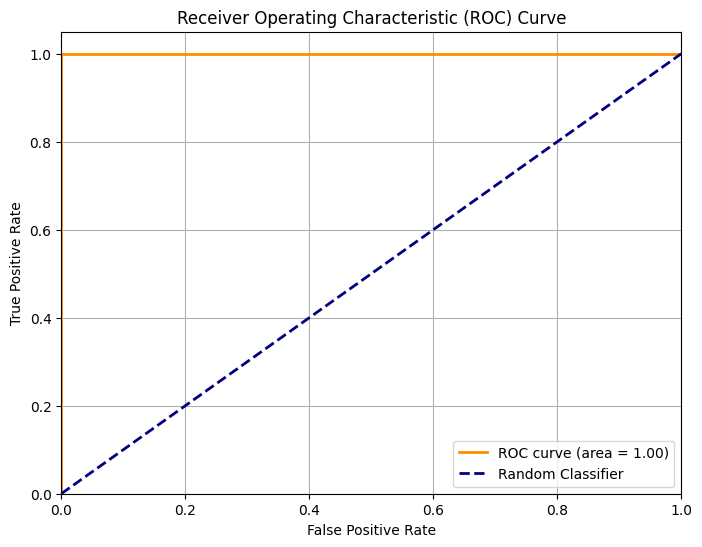

In [ ]:
 #Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Optimal Threshold (Youden's J statistic): 0.9998

Evaluation with Optimal Threshold:
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]


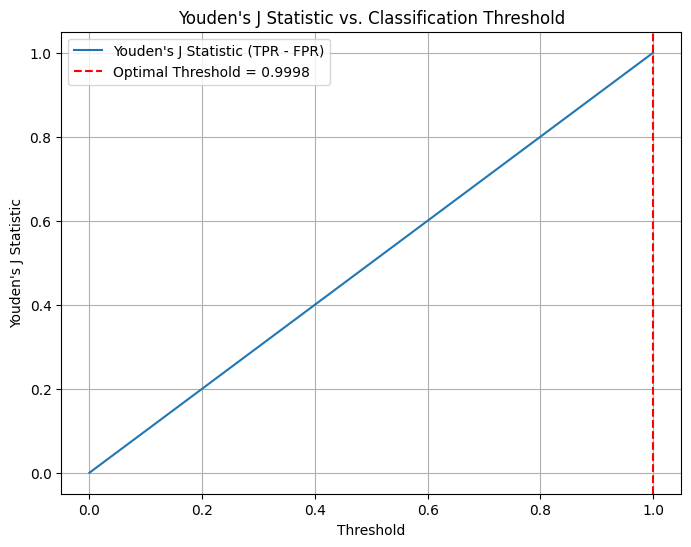

In [ ]:
#Tune threshold (not just 0.5)
# Calculate Youden's J statistic for each threshold
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Youden's J statistic): {optimal_threshold:.4f}")

# Re-evaluate the model with the optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print("\nEvaluation with Optimal Threshold:")
print("Accuracy:", accuracy_score(y_test, y_pred_optimal))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_optimal))

# Plotting Youden's J statistic vs. Thresholds
plt.figure(figsize=(8, 6))
plt.plot(thresholds, j_scores, label='Youden\'s J Statistic (TPR - FPR)')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('Youden\'s J Statistic')
plt.title("Youden's J Statistic vs. Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Add regularization (L1/L2) and compare results
# L1 Regularization (Lasso)
print("\n--- L1 Regularization (Lasso) ---")
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42) # C=0.1 for stronger regularization
model_l1.fit(X_train, y_train)

y_pred_proba_l1 = model_l1.predict_proba(X_test)[:, 1]
roc_auc_l1 = roc_auc_score(y_test, y_pred_proba_l1)

print("L1 Model Coefficients:")
for feature, coef in zip(x.columns, model_l1.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model_l1.intercept_[0]:.4f}")
print(f"L1 ROC AUC Score: {roc_auc_l1:.4f}")

# L2 Regularization (Ridge)
print("\n--- L2 Regularization (Ridge) ---")
model_l2 = LogisticRegression(penalty='l2', solver='liblinear', C=0.1, random_state=42) # C=0.1 for stronger regularization
model_l2.fit(X_train, y_train)

y_pred_proba_l2 = model_l2.predict_proba(X_test)[:, 1]
roc_auc_l2 = roc_auc_score(y_test, y_pred_proba_l2)

print("L2 Model Coefficients:")
for feature, coef in zip(x.columns, model_l2.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model_l2.intercept_[0]:.4f}")
print(f"L2 ROC AUC Score: {roc_auc_l2:.4f}")

print("\n--- Comparison ---")
print(f"Original Model ROC AUC: {roc_auc:.4f}")
print(f"L1 Regularization ROC AUC: {roc_auc_l1:.4f}")
print(f"L2 Regularization ROC AUC: {roc_auc_l2:.4f}")

print("\nObservations:")
print("- L1 regularization (Lasso) can drive some coefficients to exactly zero, effectively performing feature selection. You might observe some coefficients being 0.0000 if the regularization strength (C) is high enough.")
print("- L2 regularization (Ridge) shrinks coefficients but typically does not make them exactly zero.")
print("- For this very small dataset, the impact on ROC AUC might not be dramatic, or might even decrease if regularization is too strong, as it reduces model complexity. In larger, more complex datasets, regularization helps prevent overfitting and improves generalization.")


--- L1 Regularization (Lasso) ---
L1 Model Coefficients:
  Amount: 0.0125
  TimeSinceLastTxn: -0.0106
  LocationChange: 0.0000
  AvgTxnAmount: -0.0214
  IsForeignTransaction: 0.0000
  IsHighRiskCountry: 0.0000
  CardPresent: 0.0000
  Intercept: 0.0000
L1 ROC AUC Score: 1.0000

--- L2 Regularization (Ridge) ---
L2 Model Coefficients:
  Amount: 0.0230
  TimeSinceLastTxn: -0.0311
  LocationChange: 0.0000
  AvgTxnAmount: -0.0392
  IsForeignTransaction: 0.0000
  IsHighRiskCountry: 0.0000
  CardPresent: -0.0004
  Intercept: -0.0004
L2 ROC AUC Score: 1.0000

--- Comparison ---
Original Model ROC AUC: 1.0000
L1 Regularization ROC AUC: 1.0000
L2 Regularization ROC AUC: 1.0000

Observations:
- L1 regularization (Lasso) can drive some coefficients to exactly zero, effectively performing feature selection. You might observe some coefficients being 0.0000 if the regularization strength (C) is high enough.
- L2 regularization (Ridge) shrinks coefficients but typically does not make them exactly zer